# **Introduction to Keras using a TensorFlow 2.0 Backend**
### **Training a Simple CNN on the MNIST Dataset - Handwrittent Digits**

---



---



In this lesson, we use **Keras with a TensorFlow 2.0** Backend to to create a **simple Convolutional Neural Network model** in PyTorch and train it to **recognize handwritten digits in the MNIST dataset.**
1. Loading our MNIST dataset
2. Inspecting our dataset
3. Visualizing our image dataset
5. Preprocessing our dataset
6. Building our Model
7. Training our Model
8. Plotting our training logs
9. Saving and Loading our Model
10. Testing our model on test data

## **1. Loading our Data**

There are built in datasets from ```tensorflow.keras.datasets``` to load our data. We use the ```mnist.load_data()``` function.

Returns: **2 tuples**
- x_train, x_test: uint8 array of RGB image data with shape (num_samples, 3, 32, 32) or (num_samples, 32, 32, 3) based on the image_data_format backend setting of either channels_first or channels_last respectively.
- y_train, y_test: uint8 array of category labels (integers in range 0-9) with shape (num_samples, 1).

- More info on available datases at https://keras.io/datasets/

In [3]:
# We can load the built in datasets from this function
from tensorflow.keras.datasets import mnist

# loads the MNIST training and test dataset
(x_train, y_train), (x_test, y_test)  = mnist.load_data()

#### **A quick check to see if we're using the GPU**

In [4]:
# Check to see if we're using the GPU
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 10699397225265651531
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17731087741084414992
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


## **2. Inspecting our dataset**

In [5]:
# Display the number of samples in x_train, x_test, y_train, y_test
print("Initial shape or dimensions of x_train", str(x_train.shape))

# Print the number of samples in our data
print ("Number of samples in our training data: " + str(len(x_train)))
print ("Number of labels in our training data: " + str(len(y_train)))
print ("Number of samples in our test data: " + str(len(x_test)))
print ("Number of labels in our test data: " + str(len(y_test)))

# Print the image dimensions and no. of labels in our Training and Test Data
print("\n")
print ("Dimensions of x_train:" + str(x_train[0].shape))
print ("Labels in x_train:" + str(y_train.shape))
print("\n")
print ("Dimensions of x_test:" + str(x_test[0].shape))
print ("Labels in y_test:" + str(y_test.shape))

Initial shape or dimensions of x_train (60000, 28, 28)
Number of samples in our training data: 60000
Number of labels in our training data: 60000
Number of samples in our test data: 10000
Number of labels in our test data: 10000


Dimensions of x_train:(28, 28)
Labels in x_train:(60000,)


Dimensions of x_test:(28, 28)
Labels in y_test:(10000,)


## **3. Visualizing our image dataset**

Let’s take a look at some images in the MNIST dataset.

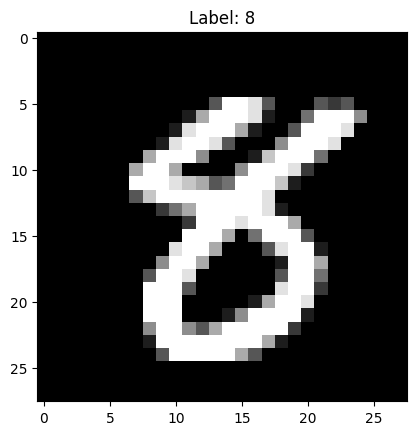

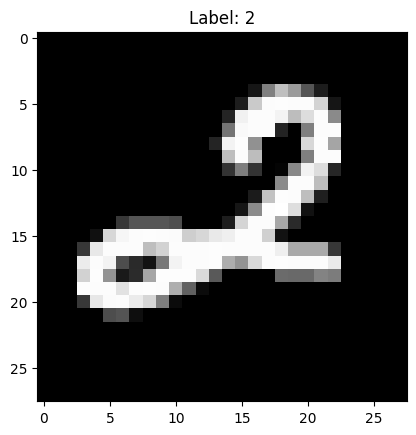

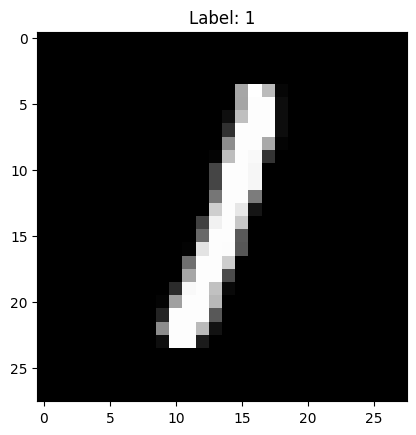

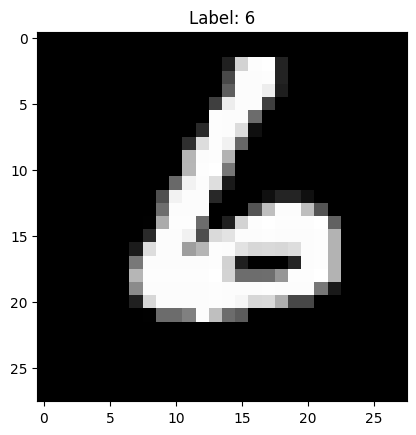

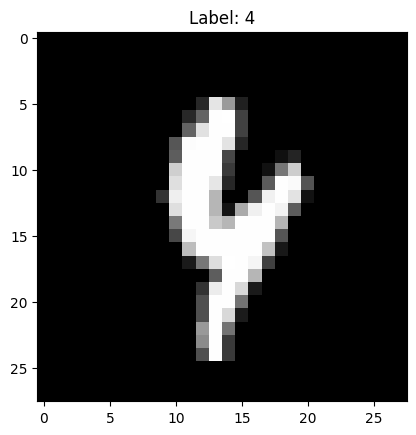

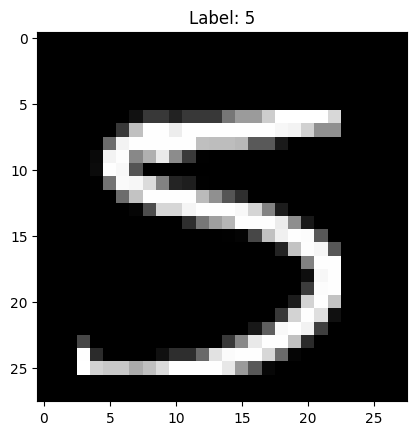

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display 6 random images
for i in range(6):
    random_num = np.random.randint(0, len(x_train))
    img = x_train[random_num]
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_train[random_num]}")
    plt.show()


### **Let's do the same thing but using matplotlib to plot 6 images**

<Figure size 640x480 with 0 Axes>

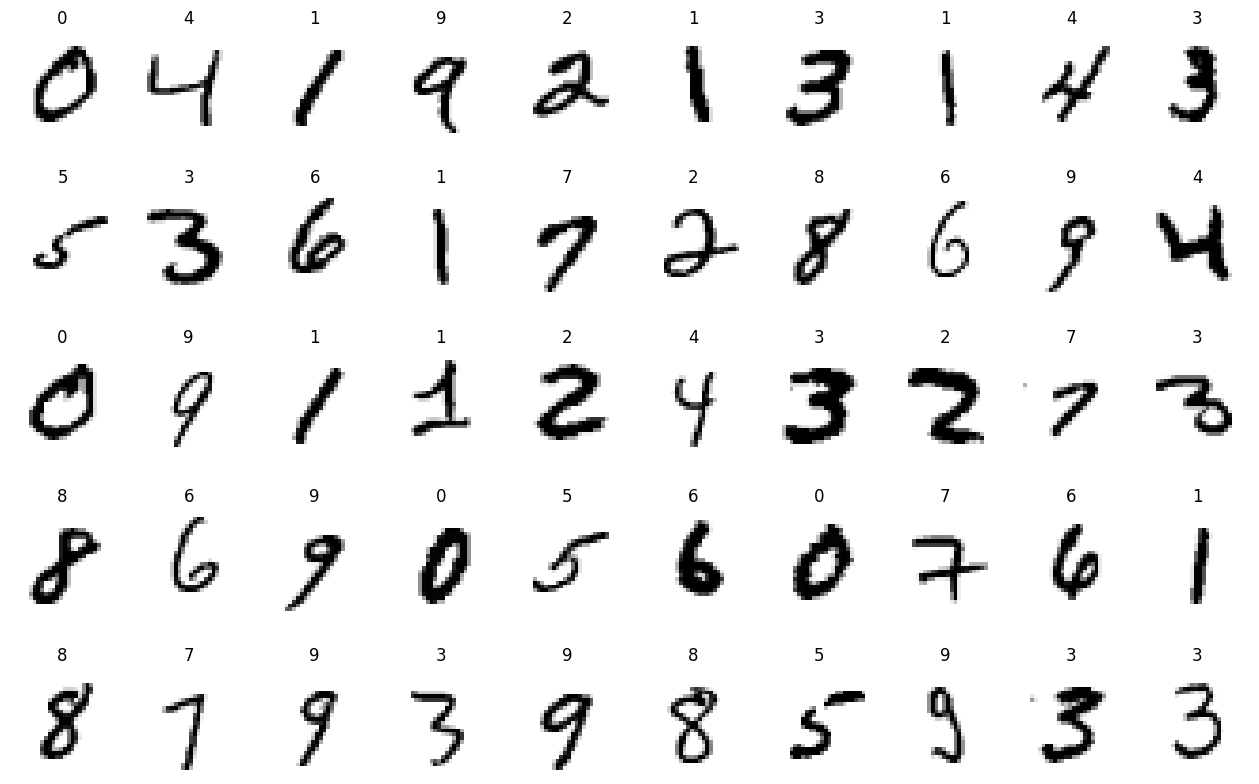

In [8]:
# Let's view the 50 first images of the MNIST training dataset
import matplotlib.pyplot as plt

# Create figure and change size
figure = plt.figure()
plt.figure(figsize=(16,10))

# Set how many images we wish to see
num_of_images = 50

# iterate index from 1 to 51
for index in range(1, num_of_images + 1):
    plt.subplot(5, 10, index).set_title(f'{y_train[index]}')
    plt.axis('off')
    plt.imshow(x_train[index], cmap='gray_r')

## 4. Preprocessing our dataset

Before passing our data to the CNN for training, we need to prepare it. This entails:

### 1. Reshaping by Adding a 4th Dimension
- MNIST images are originally shaped `(28, 28)` → just height and width.  
- CNNs expect input as `(samples, height, width, channels)`.  
- Since MNIST is grayscale, channels = 1.  
- So we reshape to `(60000, 28, 28, 1)` for training and `(10000, 28, 28, 1)` for testing.

---

### 2. Changing Datatype (uint8 → float32)
- Raw pixel values are stored as unsigned integers (0–255).  
- Neural networks work better with floating‑point numbers for gradient calculations.  
- So we convert to `float32`.

---

### 3. Normalizing Data (0–255 → 0–1)
- Pixel intensity ranges from 0 (black) to 255 (white).  
- Dividing by 255 scales values into the range **0–1**.  
- Normalization stabilizes training and speeds up convergence.

---

### 4. One‑Hot Encoding Labels
- Labels (`y_train`, `y_test`) are integers 0–9.  
- CNNs need them in vector form for classification.  
- Example: digit “3” → `[0,0,0,1,0,0,0,0,0,0]`.  
- This allows the output layer (softmax) to compare probabilities across all 10 classes.

#  Min‑Max Scaling

###  What It Does
Min‑Max scaling rescales values into a fixed range, usually **[0, 1]**.  
Formula:


\[
x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
\]



For MNIST images:
- \(x_{\text{min}} = 0\)  
- \(x_{\text{max}} = 255\)  
- So scaling is simply: \(x' = \frac{x}{255}\)

---

###  Example Matrix

**Before Scaling (pixel values 0–255):**


[[  0  64 128 255]

[200 150 100  50]

[ 30  80 220 255]

[255 180  90  10]]


**After Min‑Max Scaling (values 0–1):**

[[0.00 0.25 0.50 1.00]

[0.78 0.59 0.39 0.20]

[0.12 0.31 0.86 1.00]

[1.00 0.71 0.35 0.04]]


---

### Why It’s Useful
- Keeps all features on the same scale.  
- Prevents large values (like 255) from dominating training.  
- Helps gradient descent converge faster.  
- Makes inputs consistent across datasets.

---

# Min‑Max vs. StandardScaler

| Aspect              | Min‑Max Scaling                          | StandardScaler (Z‑Score)                  |
|---------------------|------------------------------------------|-------------------------------------------|
| Formula             | \(\frac{x - x_{\min}}{x_{\max} - x_{\min}}\) | \(\frac{x - \mu}{\sigma}\)                |
| Output Range        | Fixed range (usually [0, 1])             | Mean = 0, Std Dev = 1                     |
| Sensitive to Outliers | Yes (outliers stretch the range)         | Less sensitive (uses mean & std dev)      |
| Best Use Case       | Image pixels, bounded features           | Features with varying distributions       |

---

### Teaching Line
“Min‑Max scaling squeezes values into [0,1]. For images, this means pixel values 0–255 become decimals like 0.784. StandardScaler, on the other hand, centers values around 0 with unit variance. Min‑Max is great for bounded data like pixels, while StandardScaler is better when features follow a normal distribution.”


In [10]:
# Lets store the number of rows and columns
img_rows = x_train[0].shape[0]
img_cols = x_train[0].shape[1]

# Getting our data in the right 'shape' needed for Keras
# We need to add a 4th dimenion to our data thereby changing our
# Our original image shape of (60000,28,28) to (60000,28,28,1)
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)

# store the shape of a single image
input_shape = (img_rows, img_cols, 1)

# change our image type to float32 data type
x_train = x_train.astype('float32') #uint8 originally
x_test = x_test.astype('float32')

# Normalize our data by changing the range from (0 to 255) to (0 to 1)
x_train /= 255.0
x_test /= 255.0

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [11]:
print(img_rows, img_cols)

28 28


#### **One Hot Encode Our Labels (Y)**

We can easily implement this transformm using ```to_categorical``` from ``` tensorflow.keras.utils```

In [12]:
from tensorflow.keras.utils import to_categorical

# Now we one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Let's count the number columns in our hot encoded matrix
print ("Number of Classes: " + str(y_test.shape[1]))

num_classes = y_test.shape[1]
num_pixels = x_train.shape[1] * x_train.shape[2]

Number of Classes: 10


#### **Example of One Hot Encoding**
![Image of one hot ncoding](https://raw.githubusercontent.com/rajeevratan84/DeepLearningCV/master/hotoneencode.JPG)

In [16]:
# Look at our raw data
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## **5. Building Our Model**

![](https://github.com/rajeevratan84/ModernComputerVision/raw/main/CleanShot%202020-11-29%20at%204.21.04%402x.png)
- We're constructing a simple but effective CNN that uses 32 filters of size 3x3
- We've added a 2nd CONV layer of 64 filters of the same size 3x3
- We then downsample our data to 2x2
- We then flatten our Max Pool output that is connected to a Dense/FC layer that has an output size of 128
- Then we connect our 128 outputs to another FC/Dense layer that outputs to the 10 categorical units

## 5. Building Our CNN – Step by Step

We are constructing a simple but effective Convolutional Neural Network (CNN).  
Let’s break down each stage, what it does, and why it’s important.

---

### 1. First Convolution Layer
- **Filters:** 32 filters of size `3×3`.
- **Purpose:** Detects simple features like edges, lines, and small patterns.
- **Output:** 32 feature maps, each highlighting a different learned pattern.

---

### 2. Second Convolution Layer
- **Filters:** 64 filters of size `3×3`.
- **Purpose:** Builds on the first layer by combining simple features into more complex ones (corners, textures).
- **Output:** 64 feature maps capturing richer details.

---

### 3. Max Pooling Layer
- **Pooling Size:** `2×2`.
- **Purpose:** Downsamples the feature maps by taking the maximum value in each 2×2 block.
- **Why:**
  - Reduces spatial dimensions (height/width).
  - Keeps the strongest signals.
  - Makes the network less sensitive to small shifts/noise.
- **Output:** Smaller feature maps, same depth.

---

### 4. Flatten Layer
- **Purpose:** Converts the 2D feature maps into a 1D vector.
- **Why:** Dense (fully connected) layers require flat vectors as input.
- **Example:** If pooling output is `(14, 14, 64)`, flatten → `14×14×64 = 12,544` values.

---

### 5. Dense / Fully Connected Layer
- **Units:** 128 neurons.
- **Purpose:** Learns combinations of features to form higher‑level representations.
- **Why:** This layer acts like a traditional neural network, connecting all features together.

---

### 6. Output Dense Layer
- **Units:** 10 neurons (one for each digit class 0–9).
- **Activation:** Softmax.
- **Purpose:** Produces probability distribution across all classes.
- **Example:** `[0.01, 0.02, 0.05, 0.80, 0.03, 0.02, 0.01, 0.02, 0.02, 0.00]` → model predicts digit **3** with 80% confidence.

---

## Summary
- **Conv Layers:** Extract features (from simple edges to complex shapes).
- **Pooling:** Compresses data, keeps strongest signals.
- **Flatten:** Prepares data for dense layers.
- **Dense Layers:** Combine features into meaningful patterns.
- **Output Layer:** Classifies into 10 categories (digits 0–9).

---

  
“A CNN works like a feature‑building pipeline: convolution detects patterns, pooling compresses them, flatten prepares them, dense layers combine them, and the output layer makes the final prediction.”


In [27]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
import numpy as np

# Input shape for MNIST-like grayscale images
input_shape = (28, 28, 1)
num_classes = 10

# Build the model step by step
model = Sequential()

# 1️⃣ First Convolution Layer
# 32 filters of size 3x3, stride=1, padding='valid'
# Input: (28, 28, 1) → Output: (26, 26, 32)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))

# 2️⃣ Second Convolution Layer
# 64 filters of size 3x3, stride=1, padding='valid'
# Input: (26, 26, 32) → Output: (24, 24, 64)
model.add(Conv2D(64, (3, 3), activation='relu'))

# 3️⃣ Max Pooling Layer
# Pool size 2x2 halves the spatial dimensions
# Input: (24, 24, 64) → Output: (12, 12, 64)
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4️⃣ Flatten Layer
# Converts 3D tensor into 1D vector
# Input: (12, 12, 64) → Output: (9216,)
model.add(Flatten())

# 5️⃣ Dense Layer
# Fully connected layer with 128 neurons
# Input: (9216,) → Output: (128,)
model.add(Dense(128, activation='relu'))

# 6️⃣ Output Layer
# Fully connected layer with 10 neurons (digits 0–9)
# Input: (128,) → Output: (10,)
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=SGD(0.001),
              metrics=['accuracy'])

# Show summary of parameters and shapes
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

None


#### **Same code as above, but without the superfluous comments**

In [ ]:
y_test.shape

(10000, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import SGD

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss = 'categorical_crossentropy',
              optimizer = SGD(0.001),
              metrics = ['accuracy'])

## **6. Training our Model**
- Our preprocessed data is used as the input
- We set the batch size to 128 (or any number ranging from 8 to 256 is good)
- We set the number of epochs to 2, this is just for this tutorial purpose, but a value for at least 10 should be used
- We store our model's training results for plotting in future
- We then use Kera's molel.evaluate function to output the model's final performance. Here we are examing Test Loss and Test Accuracy

In [18]:
batch_size = 128
epochs = 25

# Store our results here so we can plot later
# In our fit function we specify our datsets (x_train & y_train),
# the batch size (typically 16 to 128 depending on your RAM), the number of
# epochs (usually 10 to 100) and our validation datasets (x_test & y_test)
# verbose = 1, sets our training to output performance metrics every epoch
history = model.fit(x_train,
                    y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    verbose = 1,
                    validation_data = (x_test, y_test))

# We obtain our accuracy score using the evalute function
# Score holds two values, our Test loss and Accuracy
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2979 - loss: 2.2397 - val_accuracy: 0.4937 - val_loss: 2.1539
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6293 - loss: 1.9035 - val_accuracy: 0.7319 - val_loss: 1.4414
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7894 - loss: 0.9480 - val_accuracy: 0.8528 - val_loss: 0.5989
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8602 - loss: 0.5221 - val_accuracy: 0.8840 - val_loss: 0.4296
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8827 - loss: 0.4184 - val_accuracy: 0.8965 - val_loss: 0.3705
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8931 - loss: 0.3727 - val_accuracy: 0.9022 - val_loss: 0.3393
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9004 - loss: 0.3451 - val_accuracy: 0.9101 - val_loss: 0.3172
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9060 - loss: 0.3252 - val_accuracy: 0

## **7. Ploting our Loss and Accuracy Charts**

In [21]:
history_dict = history.history
history_dict

{'accuracy': [0.29786667227745056,
  0.6293166875839233,
  0.7894499897956848,
  0.8601999878883362,
  0.8827166557312012,
  0.8930833339691162,
  0.9003999829292297,
  0.9059833288192749,
  0.90993332862854,
  0.9137833118438721,
  0.9173833131790161,
  0.9195500016212463,
  0.92330002784729,
  0.9253666400909424,
  0.927649974822998,
  0.9304666519165039,
  0.9330666661262512,
  0.9351500272750854,
  0.9372333288192749,
  0.9386166930198669,
  0.9408166408538818,
  0.9421666860580444,
  0.9442499876022339,
  0.9451500177383423,
  0.9471333622932434],
 'loss': [2.239696502685547,
  1.9034992456436157,
  0.9479879140853882,
  0.5221152305603027,
  0.4184059202671051,
  0.3726986050605774,
  0.34506654739379883,
  0.32517561316490173,
  0.3095054030418396,
  0.2964917719364166,
  0.28496024012565613,
  0.2745667099952698,
  0.26485657691955566,
  0.25598007440567017,
  0.24755963683128357,
  0.23985286056995392,
  0.23238591849803925,
  0.22539103031158447,
  0.2181328386068344,
  0.211

### Saving and Loadng our Model**

**Saving our Model is simple, just use:**

 ```model.save("model_file_name.h5")```

In [23]:
model.save("mnist_simple_cnn_10_Epochs.h5")
print("Model Saved")

Model Saved


**Loading our Saved Model is also simple, just use:**

```load_model(model_file_name.h5)```

In [24]:
# We need to import our load_model function
from tensorflow.keras.models import load_model

classifier = load_model('mnist_simple_cnn_10_Epochs.h5')

##  **9. Getting Predictions from our sample Test Data**

**Predicting all test data**

In [30]:
# Reshape the test data so it matches the CNN input format
# Original MNIST test data is (10000, 28, 28) → we add the channel dimension (1) for grayscale
x_test = x_test.reshape(10000, 28, 28, 1)
print(x_test.shape)   # Should print: (10000, 28, 28, 1)

print("Predicting classes for all 10,000 test images...")

# Use the trained classifier to predict probabilities for each of the 10 classes
# classifier.predict(x_test) → shape (10000, 10), each row is a probability distribution
# np.argmax(..., axis=-1) → picks the index of the highest probability (the predicted class)
pred = np.argmax(classifier.predict(x_test), axis=-1)


# Print the predictions
print(pred)           # Array of predicted labels, e.g. [7, 2, 1, 0, ...]
print(type(pred))     # Should be <class 'numpy.ndarray'>
print(len(pred))      # Should be 10000, one prediction per test image


(10000, 28, 28, 1)
Predicting classes for all 10,000 test images...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]
<class 'numpy.ndarray'>
10000


**Predicting an individual test image**

In [34]:
import matplotlib.pyplot as plt

#  Get the first image from the test set
# Original shape is (28, 28, 1) since we reshaped earlier
input_im = x_test[0]
print("Original shape of first test image:", input_im.shape)   # (28, 28, 1)

Original shape of first test image: (28, 28, 1)


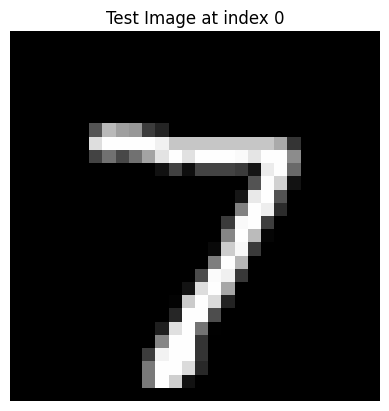

In [35]:
plt.imshow(input_im.reshape(28, 28), cmap='gray')
plt.title("Test Image at index 0")
plt.axis('off')
plt.show()

In [36]:
#  Reshape the image to add the batch dimension
# CNNs expect input as (batch_size, height, width, channels)
input_im = input_im.reshape(1, 28, 28, 1)
print("Reshaped for model input:", input_im.shape)   # (1, 28, 28, 1)

Reshaped for model input: (1, 28, 28, 1)


In [37]:
# Predict the class probabilities for this single image
# classifier.predict(input_im) → shape (1, 10), one probability per class
# np.argmax(..., axis=-1) → picks the index of the highest probability
pred = np.argmax(classifier.predict(input_im), axis=-1)

#  Print the prediction details
print("Predicted class index:", pred)      # e.g. [7]
print("Type of prediction object:", type(pred))   # numpy.ndarray
print("Length of prediction array:", len(pred))   # 1, since we predicted one image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted class index: [7]
Type of prediction object: <class 'numpy.ndarray'>
Length of prediction array: 1


In [38]:
pred_probs = classifier.predict(input_im)
pred_probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


array([[1.8022300e-06, 8.0393046e-11, 1.5374243e-04, 2.1793931e-04,
        1.0585114e-07, 9.8350065e-06, 3.4991890e-10, 9.9949801e-01,
        9.9719991e-06, 1.0853442e-04]], dtype=float32)

Class 0 → 1.8e-06 (almost 0%)

Class 1 → 8.0e-11 (basically 0%)

Class 2 → 1.5e-04 (0.015%)

Class 3 → 2.1e-04 (0.021%)

Class 4 → 1.0e-07 (0%)

Class 5 → 9.8e-06 (0.001%)

Class 6 → 3.4e-10 (0%)

Class 7 → 9.9949801e-01 (≈ 99.95%)

Class 8 → 9.9e-06 (0.001%)

Class 9 → 1.0e-04 (0.01%)

Softmax doesn’t just say ‘this is a 7.’ It produces a probability distribution across all 10 classes. Because probabilities must add up to 1, if the model is 99.95% confident about one class, the remaining 0.05% gets spread across the other nine classes. That’s why you see one big number close to 1 and nine very tiny numbers close to 0, they’re not mistakes, they’re the leftover probability mass. The tiny values are written in scientific notation (like 1.8e-06), which simply means 0.0000018